## EX 1:  Mass-spring damper system


Let us consider a mass-spring-damper system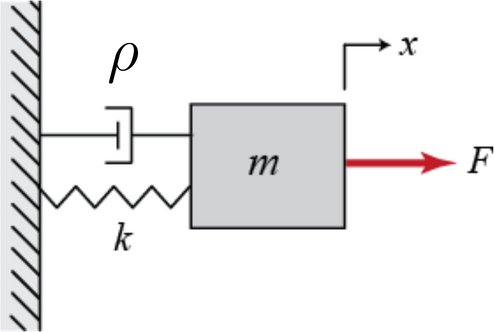

With the following system parameters:

      mass  m = 1.0 kg

      spring constant k = 5.0 N/m

      damping constant $\rho$ = 2 Ns/m

The state space model of the system is the following:

$$\dot x = Ax + Bu$$
$$ y = Cx$$

where
state vector $x = (p,v)$ (p - position, v - velocity), and state and control matrices are the following:
$$ A = \begin{pmatrix} 0&1\\ -\frac{k}{m}&-\frac{\rho}{m}\end{pmatrix},\ B = \begin{pmatrix} 0\\ \frac{1}{m} 
\end{pmatrix}$$

## TODO
1. Is the system controllable?
2. Design a PID controller that ensures that the position of the closed-loop system tracks the constant reference $y_{ref}(t) = 1.$ Plot the trajectory of the closed-loop system, starting from $x = (0,0).$ Tune PID to ensure that rising time < 10s, overshoot < 10%, Steady-state error < 2%.  
3. Design a full-state feedback controller with an integral term $u = -Kx + k_z\int_0^t(y_{ref}(\tau) - p(\tau))\,d\tau$ that ensures that the position of the closed-loop system tracks the constant reference $y_{ref}(t) = 1.$  Plot the trajectory of the closed-loop system, starting from $x = (0,0).$ Chose eigenvalues properly, to ensure that rising time < 10s, overshoot < 10%, Steady-state error < 2%.  
4. Compare the performance of PID and full-state feedback controllers. What can you say? 

Let us now work with a discretized version of the system.

5. Disretise the system with sampling time T = 0.1s
6. Design a discrete version of the PID controller that ensures that the position of the closed-loop system tracks the constant reference $y_{ref,k} = 1.$ Plot the trajectory of the closed-loop system, starting from $x = (0,0).$ Tune PID to ensure that rising time < 10s, overshoot < 10%, Steady-state error < 2%.  
7. Design a full-state feedback controller with an integral term $u_k = - Kx_k + k_z\sum_{i=0}^k(y_{ref, i} - p_i)$ that ensures that the position of the closed-loop system tracks the constant reference $y_{ref,k} = 1.$  Plot the trajectory of the closed-loop system, starting from $x = (0,0).$ Chose eigenvalues properly to ensure that rising time < 10s, overshoot < 10%, Steady-state error < 2%.  
8. Compare the performance of PID and full-state feedback controllers. What can you say?


In [6]:
# Verification if the system is controllable
import numpy as np
import control as ct

m = 1.0  # mass
k = 5.0  # spring constant
ro = 2.0  # damping coefficient

A = np.array([[0, 1], [-k / m, -ro / m]])
B = np.array([[0], [1 / m]])
C = np.array([[1, 0]])
D = np.array([[0]])


def is_controllable(A, B):
    n = A.shape[0]
    controllability_matrix = B
    for i in range(1, n):
        controllability_matrix = np.hstack(
            (controllability_matrix, np.linalg.matrix_power(A, i) @ B)
        )
    return np.linalg.matrix_rank(controllability_matrix) == n


print("Is the system controllable?", is_controllable(A, B))



Is the system controllable? True


zeta = 0.5912
wn = 3.3832
Plant G(s): <TransferFunction>: sys[12]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  -4.441e-16 s + 1
  ----------------
   s^2 + 2 s + 5
Chosen extra pole p3 = -10.0000
PID gains: Kp=46.4461, Ki=114.4609, Kd=12.0000


/home/vizanca/.eng_env/lib/python3.12/site-packages/scipy/signal/_lti_conversion.py:76: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  num, den = normalize(num, den)   # Strips zeros, checks arrays


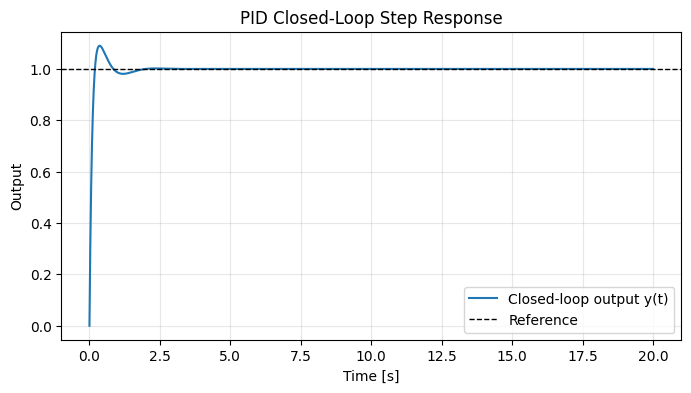

Rise time: 0.1376 s
Overshoot: 9.03 %
Steady-state error: 0.000000


In [7]:
# Performance requirements
rise_time_max = 10.0   # seconds
overshoot_max = 10.0   # percent
sse_max = 0.02         # 2%

# We choose a faster target than the maximum allowed rise time to avoid very weak gains
rise_time_target = 2.0
overshoot_target = 10.0

# 2nd-order approximation parameters from the targets
zeta = -np.log(overshoot_target / 100.0) / np.sqrt(np.pi**2 + np.log(overshoot_target / 100.0) ** 2)
wn = 4.0 / (zeta * rise_time_target)
sigma = zeta * wn
wd = wn * np.sqrt(1.0 - zeta**2)

print(f"zeta = {zeta:.4f}")
print(f"wn = {wn:.4f}")


G = ct.ss2tf(ct.ss(A, B, C, D))
print("Plant G(s):", G)

# PID: C(s) = Kp + Ki/s + Kd*s
# Closed-loop characteristic polynomial with unity feedback:
# s^3 + (2 + Kd)s^2 + (5 + Kp)s + Ki
# Choose desired polynomial as dominant pair * extra real pole
p3 = 5.0 * sigma

# (s^2 + 2*sigma*s + wn^2)*(s + p3) = s^3 + a2*s^2 + a1*s + a0
a2 = 2.0 * sigma + p3
a1 = wn**2 + 2.0 * sigma * p3
a0 = wn**2 * p3

Kd = a2 - 2.0
Kp = a1 - 5.0
Ki = a0

print(f"Chosen extra pole p3 = {-p3:.4f}")
print(f"PID gains: Kp={Kp:.4f}, Ki={Ki:.4f}, Kd={Kd:.4f}")

# Build PID and closed-loop transfer function
Cpid = ct.tf([Kd, Kp, Ki], [1, 0])
T = ct.feedback(Cpid * G, 1)

# Step response and metrics
t = np.linspace(0, 20, 2001)
t, y = ct.step_response(T, T=t)


# Optional plot
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(t, y, label="Closed-loop output y(t)")
plt.axhline(1.0, color="k", linestyle="--", linewidth=1, label="Reference")
plt.title("PID Closed-Loop Step Response")
plt.xlabel("Time [s]")
plt.ylabel("Output")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#Comando para calcular métricas de desempenho
# Compute performance metrics from step_info dictionary
info = ct.step_info(T)

tr = float(info["RiseTime"])
overshoot = float(info["Overshoot"])
sse = abs(1.0 - float(info["SteadyStateValue"]))

print(f"Rise time: {tr:.4f} s")
print(f"Overshoot: {overshoot:.2f} %")
print(f"Steady-state error: {sse:.6f}")

Ganho K: [21.  7.]
Ganho kz: 24.000000000000618


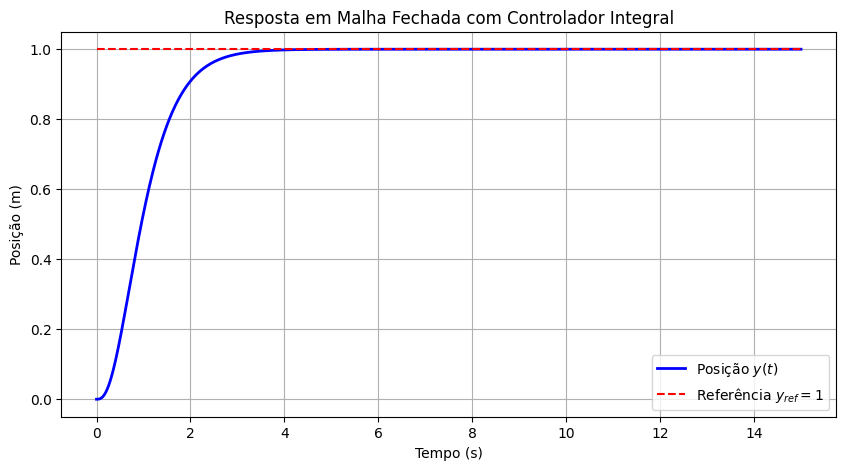

Rise time: 1.5542 s
Overshoot: 0.00 %
Steady-state error: 0.000000


In [8]:


# 2. Matrizes do Sistema Aumentado
# Aa = [ A   0 ]
#      [-C   0 ]
Aa = np.block([
    [A, np.zeros((2, 1))],
    [-C, np.zeros((1, 1))]
])

# Ba = [ B ]
#      [ 0 ]
Ba = np.block([
    [B],
    [np.zeros((1, 1))]
])

# 3. Alocação de Polos
# Polos desejados para atingir as restrições de tempo e sobressinal
p = [-2, -3, -4]

# Calcula os ganhos K_a usando o método place
#Como se estivesse fazendo Ackermann, mas usando place para o sistema aumentado
# Formula Ackermann: K = [0 0 1] * inv(controllability_matrix) * desired_char_poly(A).
# polinomio característico desejado: (s+2)(s+3)(s+4) = s^3 + 9s^2 + 26s + 24
# Portanto A = A^3 + 9A^2 + 26A + 24I
# 
Ka = ct.place(Aa, Ba, p)

# Extrai os ganhos (lembrando que u = -Ka * x_a = -K*x - k3*z, e queremos + kz*z)
K = Ka[0, 0:2]
kz = -Ka[0, 2]

print(f"Ganho K: {K}")
print(f"Ganho kz: {kz}")

# 4. Simulação em Malha Fechada
# O sistema em malha fechada aumentado é x_a_dot = (Aa - Ba*Ka)*x_a + B_ref * y_ref
A_cl = Aa - Ba @ Ka

# A entrada de referência y_ref entra na derivada do integrador: z_dot = y_ref - y
B_cl = np.array([[0], 
                 [0], 
                 [1]])

# Queremos observar a posição, que é o primeiro estado x1
C_cl = np.array([[1, 0, 0]])
D_cl = np.array([[0]])

sys_cl = ct.StateSpace(A_cl, B_cl, C_cl, D_cl)

# Vetor de tempo (0 a 15 segundos) e referência (degrau unitário)
t = np.linspace(0, 15, 1000)
y_ref = np.ones_like(t)

# Simulando o sistema partindo de x = (0,0) e integrador = 0
t, y = ct.forced_response(sys_cl, T=t, U=y_ref, X0=[0, 0, 0])

# 5. Plotagem
plt.figure(figsize=(10, 5))
plt.plot(t, y, label='Posição $y(t)$', color='blue', linewidth=2)
plt.plot(t, y_ref, '--', label='Referência $y_{ref} = 1$', color='red')
plt.title('Resposta em Malha Fechada com Controlador Integral')
plt.xlabel('Tempo (s)')
plt.ylabel('Posição (m)')
plt.grid(True)
plt.legend()
plt.show()

info = ct.step_info(sys_cl)
tr = float(info["RiseTime"])
overshoot = float(info["Overshoot"])
sse = abs(1.0 - float(info["SteadyStateValue"]))
print(f"Rise time: {tr:.4f} s")
print(f"Overshoot: {overshoot:.2f} %")
print(f"Steady-state error: {sse:.6f}")

Both the PID and the Full-State Feedback with Integral Action (FSFB+I) controllers did exactly what they were supposed to do in terms of eliminating steady-state error, both hitting a perfect 0.00%. However, the way they get to the target is very different. The PID controller reacted incredibly fast, clocking a rise time of just 0.1376 seconds. But this aggressive push comes with a catch: the intrinsic zeros in its closed-loop transfer function caused a noticeable 9.03% overshoot. On the flip side, the FSFB+I approach behaves much more smoothly. Because the reference signal is fed strictly through the integrator state, it avoids introducing those problematic zeros altogether. As a result, the FSFB+I tracked our chosen real poles perfectly, delivering a clean step response with zero overshoot and a very comfortable 1.5542-second rise time. While both designs easily met the sub-10-second requirement, the FSFB+I traded the PID's hyper-fast, oscillatory reaction for a much more stable and predictable response.

----------


### Discretized Control

In [16]:
Ts = 0.1  



# 2. Discretize the plant using Zero-Order Hold (ZOH)
sys_c = ct.StateSpace(A, B, C, D)
sys_d = ct.c2d(sys_c, Ts, method='zoh')
Ad = sys_d.A
Bd = sys_d.B
Cd = sys_d.C

# 3. Build the discrete augmented system
# Augmented state vector: [x1(k), x2(k), z(k)]^T
A_ad = np.block([
    [Ad, np.zeros((2, 1))],
    [-Ts * Cd, np.eye(1)]
])

B_ad = np.block([
    [Bd],
    [np.zeros((1, 1))]
])

# 4. Map the continuous poles to the discrete domain (z = e^(s*Ts))
continuous_poles = np.array([-2.0, -3.0, -4.0])
discrete_poles = np.exp(continuous_poles * Ts)




### PID EU NAO SEI

Mapped Discrete Poles: [0.81873075 0.74081822 0.67032005]
Discrete Gain K: [15.40672083  5.25005488]
Discrete Gain kz: 17.16074393895337


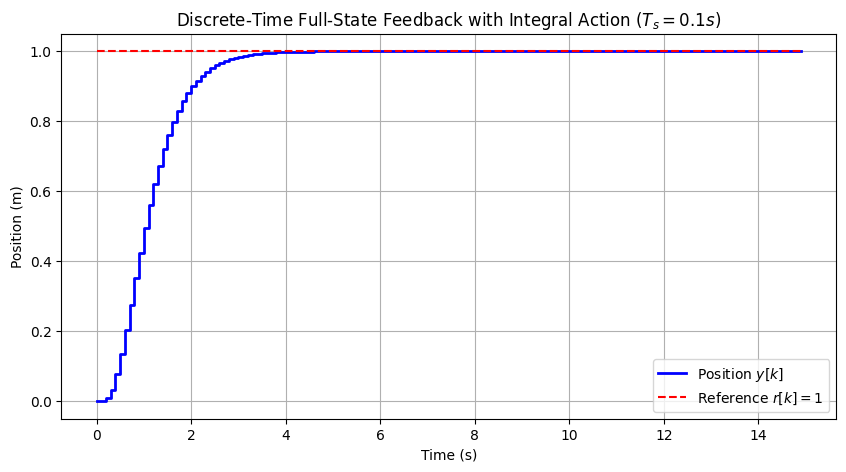

Rise time: 1.6000 s
Overshoot: 0.00 %
Steady-state error: 0.000000


In [18]:
#FeedBack control design using pole placement for the discrete augmented system


# 5. Calculate the feedback gains using pole placement
Ka = ct.place(A_ad, B_ad, discrete_poles)

# Extract K and kz (Control law: u = -K*x + kz*z)
# The output from place gives u = -Ka * x_augmented = -K*x - (-kz)*z
K = Ka[0, 0:2]
kz = -Ka[0, 2] 

print(f"Mapped Discrete Poles: {discrete_poles}")
print(f"Discrete Gain K: {K}")
print(f"Discrete Gain kz: {kz}")

# 6. Simulate the system using a manual loop (Microcontroller logic)
t_sim = 15.0
n_steps = int(t_sim / Ts)
t = np.arange(0, n_steps * Ts, Ts)
r = np.ones_like(t)  # Unit step reference

# Initialize state and output arrays
x = np.zeros((2, 1)) # Plant states (position, velocity)
z = 0.0              # Integrator state
y = np.zeros(n_steps)
u = np.zeros(n_steps)

# The control loop running at every sample time Ts
for i in range(n_steps):
    # 6.1 Read the current output (sensor measurement)
    y[i] = (Cd @ x)[0, 0]
    
    # 6.2 Calculate the control action
    u_k = -K @ x + kz * z
    u[i] = u_k[0]
    
    # 6.3 Plant dynamics update (simulating physical physics for the next step)
    x_next = Ad @ x + Bd * u_k
    
    # 6.4 Integrator update using Forward Euler: z(k+1) = z(k) + Ts * error
    error = r[i] - y[i]
    z_next = z + Ts * error
    
    # 6.5 Update variables for the next iteration
    x = x_next
    z = z_next

# 7. Plotting the results
plt.figure(figsize=(10, 5))
plt.step(t, y, where='post', label='Position $y[k]$', color='blue', linewidth=2)
plt.plot(t, r, '--', label='Reference $r[k] = 1$', color='red')
plt.title('Discrete-Time Full-State Feedback with Integral Action ($T_s = 0.1s$)')
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.grid(True)
plt.legend()
plt.show()


#closed-loop system for step response analysis
A_cl = A_ad - B_ad @ Ka
B_cl = np.array([[0],
                 [0],
                 [Ts]])  # Reference input affects only the integrator state
C_cl = np.array([[1, 0, 0]])  # We want to observe the position output
D_cl = np.array([[0]])

sys_cl = ct.StateSpace(A_cl, B_cl, C_cl, D_cl, dt=Ts)
info = ct.step_info(sys_cl)
tr = float(info["RiseTime"])   
overshoot = float(info["Overshoot"])
sse = abs(1.0 - float(info["SteadyStateValue"]))
print(f"Rise time: {tr:.4f} s")
print(f"Overshoot: {overshoot:.2f} %")
print(f"Steady-state error: {sse:.6f}")


## Ex 2. Quadruple-Tank Process

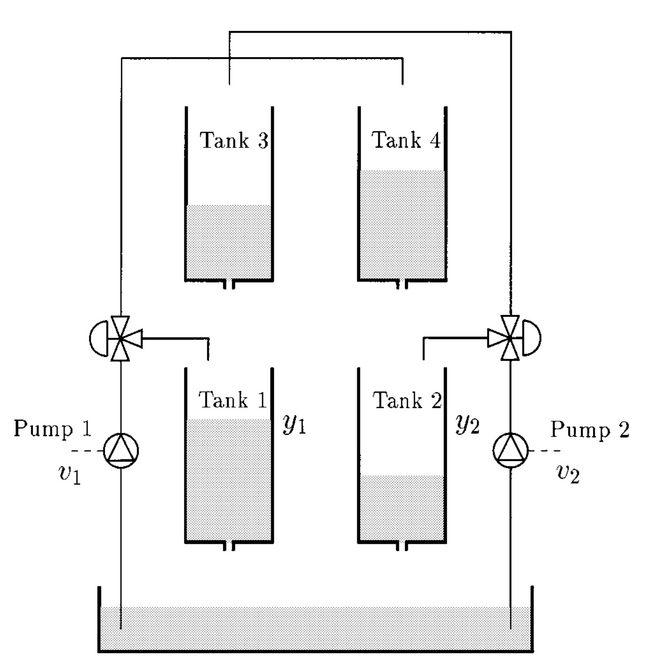

Let us consider the Quadruple-Tank Process. A schematic diagram of the process is shown in the Figure above. The
target is to control the level in the lower two tanks with two pumps. The process inputs are $v_1$ and $v_2$ (input voltages to the pumps) and the outputs are $y_1$ and $y_2$ (voltages from level measurement devices). Mass balances and Bernoulli’s law yield

$$
\dfrac{dh_1}{dt} = -\dfrac{a_1}{A_1}\sqrt{2gh_1} + \dfrac{a_3}{A_1}\sqrt{2gh_3} + \dfrac{\gamma_1k_1}{A_1}v_1 = f_1(h_1,h_2,h_3,h_4,v_1,v_2)
$$

$$
\dfrac{dh_2}{dt} = -\dfrac{a_2}{A_2}\sqrt{2gh_2} + \dfrac{a_4}{A_2}\sqrt{2gh_4} + \dfrac{\gamma_2k_2}{A_2}v_2 = f_2(h_1,h_2,h_3,h_4,v_1,v_2)
$$

$$
\dfrac{dh_3}{dt} = -\dfrac{a_3}{A_3}\sqrt{2gh_3} + \dfrac{(1-\gamma_2)k_2}{A_3}v_2 = f_3(h_1,h_2,h_3,h_4,v_1,v_2)
$$

$$
\dfrac{dh_4}{dt} = -\dfrac{a_4}{A_4}\sqrt{2gh_4} + \dfrac{(1-\gamma_1)k_1}{A_4}v_1 = f_4(h_1,h_2,h_3,h_4,v_1,v_2)
$$

where

$A_i$ is a cross-section of Tank i

$a_i$ is a cross-section of outlet hole of Tank i

$h_i$ is a water level.

The voltage applied to Pump $i$ is $v_i$ and the corresponding flow
is $k_iv_i$. The parameters $\gamma_1,\gamma_2\in (0,1)$ are determined from how the valves are set prior to experiment. The flow to Tank 1
is $\gamma_1k_1v_1$ and the flow to Tank 4 is $(1-\gamma_1)k_1v_1$ and similarly
for Tank 2 and Tank 3. The acceleration of gravity is denoted $g$.
The measured level signals are $k_c h_1$ and $k_c h_2$. The parameter
values of the laboratory process are given in the following table

    A_1, A_3 [cm^2] 28
    A_2, A_4 [cm^2] 32
    a_1, a_3 [cm^2] 0.071
    a_2, a_4 [cm^2] 0.057
    k_c [V/cm] 0.50
    g [cm/s^2] 9.81
    k_1 [cm^3/Vs] 3.33
    k_2 [cm^3/Vs] 3.35
    gamma_1 0.70
    gamma_2 0.60
    
Check the following paper for more details on the model. 
https://www.diva-portal.org/smash/get/diva2:495784/FULLTEXT01.pdf

## TODO
1. Linearise the system around the operating point 
$$(h_1^0,h_2^0,h_3^0,h_4^0, v_1^0, v_2^0) = (12.4,12.7,1.8,1.4,3.00,3.00).$$
Pass to shifted variables $x_i = h_i-h_i^0, u_i = v_i - v_i^0.$

2. Is the linear system controllable? Is the linear system observable? Use the Kalman rank test to answer this question.

3. Imagine that one of the pumps is broken and there is no flow through it. Does the system remain controllable?

4. Let us measure the signals $x_3, x_4$ instead of measuring the signals $x_1$ and $x_2,$ I .e matrix
   $$C= \begin{pmatrix} 0&0&1&0\\ 0&0&0&1 \end{pmatrix}$$
   instead of
   $$C= \begin{pmatrix} 1&0&0&0\\ 0&1&0&0 \end{pmatrix}.$$
 Is such a system observable?

## EX3: Inverted Pendulum

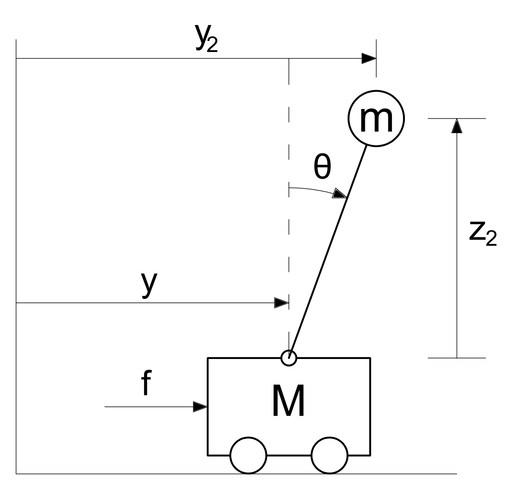
The system in this example consists of an inverted pendulum mounted to a motorized cart. The inverted pendulum system is an example commonly found in control system textbooks and research literature. Its popularity derives in part from the fact that it is unstable without control, that is, the pendulum will simply fall over if the cart isn't moved to balance it. Additionally, the dynamics of the system are nonlinear. The objective of the control system is to balance the inverted pendulum by applying a force to the cart that the pendulum is attached to. A real-world example that relates directly to this inverted pendulum system is the attitude control of a booster rocket at takeoff.
The system in this example consists of an inverted pendulum mounted to a motorized cart. The inverted pendulum system is an example commonly found in control system textbooks and research literature. Its popularity derives in part from the fact that it is unstable without control, that is, the pendulum will simply fall over if the cart isn't moved to balance it. Additionally, the dynamics of the system are nonlinear. The objective of the control system is to balance the inverted pendulum by applying a force to the cart that the pendulum is attached to. A real-world example that relates directly to this inverted pendulum system is the attitude control of a booster rocket at takeoff.


Let us consider the system with the following system parameters

    (M)       mass of the cart                         0.5 kg
    
    (m)       mass of the pendulum                     0.2 kg
    
    (l)       length to pendulum center of mass        0.3 m
    
    (b)       coefficient of friction for cart         0.1 N/m/sec
    
    (I)       mass moment of inertia of the pendulum   0.006 kg.m^2
    
    (F)       force applied to the cart
    
    (y)       cart position coordinate
    
    (theta)   angle between the pendulum and the vertical axis

## TODO

1) Show that the inverted pendulum on the cart can be modeled as follows

$$(M+m)\ddot{y} + b\dot{y} + ml\ddot{\theta}\cos\theta -ml\dot\theta^2\sin(\theta) = F$$

$$ml\cos(\theta)\ddot{y} + (I+ml^2)\ddot{\theta} - mgl\sin\theta = 0$$    

2) Let the state vector $x = (y,y_1,\theta,\theta_1),$ where $y_1 = \dot{y}$ and $\theta_1 = \dot{\theta}.$ Lineralize the system around equlibrium  point $x = (0,0,0,0).$

3) Is the autonomous system stable (u = 0)? Is the system controllable? Design a full state feedback controller $u = -Kx$ assigning the following eigenvalues $\lambda_1 = - 1, \lambda_2 = -2, \lambda_3 = -1.5, \lambda_4 = -2.5$ in the closed-loop system. Is a closed-loop system stable?

4) Let us assume that we only measure the position $y$ and the angular velocitity $\theta$. What is the right matrix C? Is the system observable?

5) Design an optimal estimator and an optimal estimated-state-feedback controller (both via LQR design as discussed in the lecture) which stabilize the system in (0,0,0,0).

6) Use the following library to implement an MPC controller
    https://github.com/forgi86/pyMPC/blob/master/README.md
   that stabilize the system while ensuring that following state and input constraints are satisfied

   $x_{min} = [-5,-100,-100,-100]\leq x \leq x_{max}= [5,100,100,100]$
   
   $u_{min} = -20 \leq u\leq u_{max}=20$
   
   The following notebook can be useful for you 
   https://github.com/forgi86/pyMPC/blob/master/examples/example_inverted_pendulum.ipynb
   